In [44]:
import cv2
import numpy as np
import os


# ============================================================
# FUNCTION 1: Detect boundary points from all rows
# ============================================================

def detect_boundaries(frame, threshold=600):

    height, width = frame.shape[:2]

    # Brightness = B + G + R
    brightness = np.sum(frame[:, :, :3], axis=2)

    left_points = []
    right_points = []

    # --------------------------------------------------------
    # Process every row
    # --------------------------------------------------------

    for v in range(height):

        row = brightness[v]

        # ====================================================
        # LEFT HALF: u < 240
        # ====================================================

        left = row[:240]

        max_left = np.max(left)

        if max_left >= threshold:

            # All pixels having the maximum brightness
            pixels = np.where(left == max_left)[0]

            # Average their u coordinates
            left_u = np.mean(pixels)

            left_points.append((v, left_u))


        # ====================================================
        # RIGHT HALF: u >= 240
        # ====================================================

        right = row[240:]

        max_right = np.max(right)

        if max_right >= threshold:

            # All pixels having the maximum brightness
            pixels = np.where(right == max_right)[0]

            # Convert local coordinate to image coordinate
            right_u = np.mean(pixels) + 240

            right_points.append((v, right_u))


    return brightness, left_points, right_points


# ============================================================
# FUNCTION 2: Estimate lane for one frame
# ============================================================

def estimate_lane(frame, threshold=600):

    brightness, left_points, right_points = detect_boundaries(
        frame,
        threshold
    )

    # Convert to numpy arrays
    left_points = np.array(left_points)
    right_points = np.array(right_points)


    # --------------------------------------------------------
    # Fit regression to left boundary
    # u = a*v + b
    # --------------------------------------------------------

    left_v = left_points[:, 0]
    left_u = left_points[:, 1]

    left_slope, left_intercept = np.polyfit(
        left_v,
        left_u,
        1
    )


    # --------------------------------------------------------
    # Fit regression to right boundary
    # u = a*v + b
    # --------------------------------------------------------

    right_v = right_points[:, 0]
    right_u = right_points[:, 1]

    right_slope, right_intercept = np.polyfit(
        right_v,
        right_u,
        1
    )


    # ========================================================
    # MSE of the two regression lines
    # ========================================================

    left_pred = left_slope * left_v + left_intercept
    right_pred = right_slope * right_v + right_intercept

    left_mse = np.mean((left_u - left_pred) ** 2)
    right_mse = np.mean((right_u - right_pred) ** 2)


    # ========================================================
    # Function for obtaining a boundary at a particular row
    # ========================================================

    def get_boundary(v, side):

        # ----------------------------------------------------
        # LEFT
        # ----------------------------------------------------

        if side == "left":

            row = brightness[v, :240]

            max_value = np.max(row)

            # If actual boundary evidence exists
            if max_value >= threshold:

                pixels = np.where(
                    row == max_value
                )[0]

                u = np.mean(pixels)

                return u, "actual"


            # Otherwise use regression
            else:

                u = (
                    left_slope * v
                    + left_intercept
                )

                return u, "regression"


        # ----------------------------------------------------
        # RIGHT
        # ----------------------------------------------------

        else:

            row = brightness[v, 240:]

            max_value = np.max(row)

            # If actual boundary evidence exists
            if max_value >= threshold:

                pixels = np.where(
                    row == max_value
                )[0]

                u = np.mean(pixels) + 240

                return u, "actual"


            # Otherwise use regression
            else:

                u = (
                    right_slope * v
                    + right_intercept
                )

                return u, "regression"


    # ========================================================
    # FAR ROW
    # ========================================================

    vf = 170

    left_far, left_far_source = get_boundary(
        vf,
        "left"
    )

    right_far, right_far_source = get_boundary(
        vf,
        "right"
    )

    uf = (left_far + right_far) / 2


    # ========================================================
    # NEAR ROW
    # ========================================================

    vn = 260

    left_near, left_near_source = get_boundary(
        vn,
        "left"
    )

    right_near, right_near_source = get_boundary(
        vn,
        "right"
    )

    un = (left_near + right_near) / 2


    # ========================================================
    # CONFIDENCE INTERVAL LOGIC
    # ========================================================

    # -------------------------
    # FAR confidence
    # -------------------------

    if (
        left_far_source == "actual"
        and
        right_far_source == "actual"
    ):

        confidence_far = 1.0

    elif (
        left_far_source == "actual"
        and
        right_far_source == "regression"
    ):

        confidence_far = 0.75 - right_mse / 10

    elif (
        left_far_source == "regression"
        and
        right_far_source == "actual"
    ):

        confidence_far = 0.75 - left_mse / 10

    else:

        confidence_far = (
            0.50
            - left_mse / 10
            - right_mse / 10
        )


    # -------------------------
    # NEAR confidence
    # -------------------------

    if (
        left_near_source == "actual"
        and
        right_near_source == "actual"
    ):

        confidence_near = 1.0

    elif (
        left_near_source == "actual"
        and
        right_near_source == "regression"
    ):

        confidence_near = 0.75 - right_mse / 10

    elif (
        left_near_source == "regression"
        and
        right_near_source == "actual"
    ):

        confidence_near = 0.75 - left_mse / 10

    else:

        confidence_near = (
            0.50
            - left_mse / 10
            - right_mse / 10
        )


    # ========================================================
    # Return everything
    # ========================================================

    return {

        "un": round(un),
        "uf": round(uf),

        "confidence_near": confidence_near,
        "confidence_far": confidence_far,

        "left_far": left_far,
        "right_far": right_far,

        "left_near": left_near,
        "right_near": right_near,

        "left_far_source": left_far_source,
        "right_far_source": right_far_source,

        "left_near_source": left_near_source,
        "right_near_source": right_near_source,

        "left_mse": left_mse,
        "right_mse": right_mse,

        "left_points": left_points,
        "right_points": right_points,

        "left_line": (
            left_slope,
            left_intercept
        ),

        "right_line": (
            right_slope,
            right_intercept
        )
    }


# ============================================================
# FUNCTION 3: Process entire folder
# ============================================================

def process_folder(folder, threshold=600):

    files = sorted(os.listdir(folder))

    for file in files:

        if not file.endswith(".png"):
            continue

        path = os.path.join(folder, file)

        frame = cv2.imread(path)

        if frame is None:
            continue

        result = estimate_lane(
            frame,
            threshold
        )

        print(
            file,
            result["un"],
            round(result["confidence_near"], 4),
            result["uf"],
            round(result["confidence_far"], 4)
        )


# ============================================================
# RUN
# ============================================================

process_folder("clear", threshold=600)# ============================================================


000.png 242 1.0 243 1.0
001.png 242 1.0 244 1.0
002.png 244 1.0 245 1.0
003.png 244 1.0 246 1.0
004.png 246 1.0 246 1.0
005.png 247 1.0 247 1.0
006.png 248 1.0 248 1.0
007.png 249 1.0 249 1.0
008.png 250 1.0 249 1.0
009.png 251 1.0 250 1.0
010.png 252 1.0 250 1.0
011.png 252 1.0 251 1.0
012.png 253 1.0 251 1.0
013.png 254 1.0 251 1.0
014.png 254 1.0 251 1.0
015.png 254 1.0 252 1.0
016.png 254 1.0 252 1.0
017.png 254 1.0 252 1.0
018.png 254 1.0 251 1.0
019.png 254 1.0 251 1.0
020.png 254 1.0 251 1.0
021.png 254 1.0 251 1.0
022.png 254 1.0 250 1.0
023.png 254 1.0 250 1.0


In [45]:
# ============================================================
# FUNCTION 3: Process entire folder
# ============================================================

def process_folder(folder, threshold=600):

    files = sorted(os.listdir(folder))

    for file in files:

        if not file.endswith(".png"):
            continue

        path = os.path.join(folder, file)

        frame = cv2.imread(path)

        if frame is None:
            continue

        result = estimate_lane(
            frame,
            threshold
        )

        print(
            file,
            result["un"],
            round(result["confidence_near"], 4),
            result["uf"],
            round(result["confidence_far"], 4)
        )


# ============================================================
# RUN
# ============================================================

process_folder("missing", threshold=600)# ============================================================


000.png 241 0.7291 243 0.7287
001.png 242 0.7217 244 0.7288
002.png 243 0.7287 245 0.7306
003.png 244 1.0 245 0.4568
004.png 246 1.0 246 0.4575
005.png 247 1.0 247 0.4584
006.png 248 1.0 248 0.457
007.png 249 1.0 248 0.452
008.png 250 1.0 249 0.4587
009.png 251 1.0 250 0.4623
010.png 252 1.0 250 0.4623
011.png 252 1.0 250 0.4618
012.png 253 1.0 250 0.7316
013.png 254 1.0 251 0.7304
014.png 254 1.0 251 0.7312
015.png 254 1.0 252 0.7288
016.png 254 1.0 252 0.7295
017.png 254 1.0 252 0.7317
018.png 254 1.0 251 0.7312
019.png 254 1.0 251 0.7304
020.png 254 1.0 251 0.7318
021.png 254 1.0 251 0.7268
022.png 254 0.7319 250 0.7319
023.png 252 0.7279 249 0.7279


In [46]:
# ============================================================
# FUNCTION 3: Process entire folder
# ============================================================

def process_folder(folder, threshold=600):

    files = sorted(os.listdir(folder))

    for file in files:

        if not file.endswith(".png"):
            continue

        path = os.path.join(folder, file)

        frame = cv2.imread(path)

        if frame is None:
            continue

        result = estimate_lane(
            frame,
            threshold
        )

        print(
            file,
            result["un"],
            round(result["confidence_near"], 4),
            result["uf"],
            round(result["confidence_far"], 4)
        )


# ============================================================
# RUN
# ============================================================

process_folder("shadow", threshold=600)# ============================================================


000.png 241 0.7357 242 1.0
001.png 242 0.7317 244 1.0
002.png 243 0.7356 245 0.7356
003.png 244 0.7348 245 0.7348
004.png 246 1.0 246 0.7364
005.png 246 1.0 247 0.736
006.png 248 1.0 248 0.7355
007.png 249 1.0 248 0.7336
008.png 250 1.0 249 0.7352
009.png 250 1.0 250 0.7355
010.png 251 1.0 250 0.7368
011.png 252 1.0 250 0.7373
012.png 252 1.0 251 0.7337
013.png 253 1.0 250 1.0
014.png 254 1.0 251 1.0
015.png 254 1.0 252 1.0
016.png 254 1.0 251 1.0
017.png 254 1.0 252 1.0
018.png 254 1.0 251 1.0
019.png 254 1.0 250 1.0
020.png 254 1.0 250 1.0
021.png 254 1.0 250 0.7121
022.png 254 0.7373 250 0.7373
023.png 252 0.7285 249 0.7285


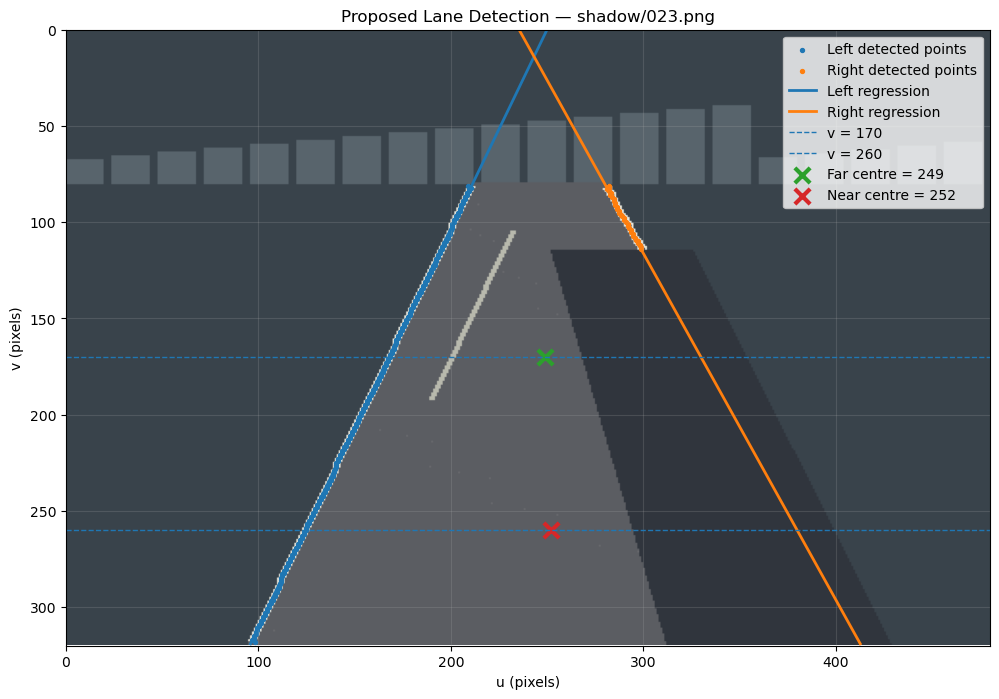

Frame: shadow/023.png

Far row (v = 170)
Left boundary: 168.5 → actual
Right boundary: 329.87 → regression
Far centre: 249

Near row (v = 260)
Left boundary: 124.5 → actual
Right boundary: 379.88 → regression
Near centre: 252


In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load shadow/023.png
# ------------------------------------------------------------

frame = cv2.imread("missing/023.png")
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# ------------------------------------------------------------
# Run your proposed method
# ------------------------------------------------------------

result = estimate_lane(frame, threshold=600)

# Extract results
left_points = result["left_points"]
right_points = result["right_points"]

left_slope, left_intercept = result["left_line"]
right_slope, right_intercept = result["right_line"]

un = result["un"]
uf = result["uf"]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

plt.imshow(frame_rgb)

# ------------------------------------------------------------
# Plot all actual detected boundary points
# ------------------------------------------------------------

if len(left_points) > 0:
    plt.scatter(
        left_points[:, 1],
        left_points[:, 0],
        s=8,
        label="Left detected points"
    )

if len(right_points) > 0:
    plt.scatter(
        right_points[:, 1],
        right_points[:, 0],
        s=8,
        label="Right detected points"
    )

# ------------------------------------------------------------
# Plot regression lines
# ------------------------------------------------------------

v = np.arange(0, frame.shape[0])

left_fit = left_slope * v + left_intercept
right_fit = right_slope * v + right_intercept

plt.plot(
    left_fit,
    v,
    linewidth=2,
    label="Left regression"
)

plt.plot(
    right_fit,
    v,
    linewidth=2,
    label="Right regression"
)

# ------------------------------------------------------------
# Required rows
# ------------------------------------------------------------

plt.axhline(
    170,
    linestyle="--",
    linewidth=1,
    label="v = 170"
)

plt.axhline(
    260,
    linestyle="--",
    linewidth=1,
    label="v = 260"
)

# ------------------------------------------------------------
# Plot final lane centres
# ------------------------------------------------------------

plt.scatter(
    uf,
    170,
    s=120,
    marker="x",
    linewidths=3,
    label=f"Far centre = {uf}"
)

plt.scatter(
    un,
    260,
    s=120,
    marker="x",
    linewidths=3,
    label=f"Near centre = {un}"
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xlim(0, 480)
plt.ylim(320, 0)

plt.xlabel("u (pixels)")
plt.ylabel("v (pixels)")

plt.title(
    "Proposed Lane Detection — shadow/023.png"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ============================================================
# PRINT EXACT SOURCE OF EACH ESTIMATE
# ============================================================

print("Frame: shadow/023.png")

print("\nFar row (v = 170)")
print(
    "Left boundary:",
    round(result["left_far"], 2),
    "→",
    result["left_far_source"]
)
print(
    "Right boundary:",
    round(result["right_far"], 2),
    "→",
    result["right_far_source"]
)
print("Far centre:", result["uf"])


print("\nNear row (v = 260)")
print(
    "Left boundary:",
    round(result["left_near"], 2),
    "→",
    result["left_near_source"]
)
print(
    "Right boundary:",
    round(result["right_near"], 2),
    "→",
    result["right_near_source"]
)
print("Near centre:", result["un"])